In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
import pickle

##########################################
# PART 1: TRAINING CODE - Build and Save GRU Model
##########################################

# Load the CSV with the 'cell_stack_sequence' column
csv_file = 'simplified_cell_stacks_filtered.csv'
df = pd.read_csv(csv_file)
sequences_text = df['cell_stack_sequence'].tolist()

# Create and fit the tokenizer (with an out-of-vocabulary token)
tokenizer = Tokenizer(filters='', split=None, oov_token='<OOV>')
tokenizer.fit_on_texts(sequences_text)
sequences = tokenizer.texts_to_sequences(sequences_text)

# Determine vocabulary size and pad sequences (using post padding)
vocab_size = len(tokenizer.word_index) + 1
max_sequence_length = max(len(seq) for seq in sequences)
sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

# Prepare training data for language modeling:
# X_train: all tokens except the last; y_train: all tokens except the first.
X_train = sequences[:, :-1]
y_train = sequences[:, 1:]

# -------------------------------
# Build the GRU-based Language Model
# -------------------------------

# Hyperparameters
embedding_dim = 128   # Embedding size for each token
gru_units = 256       # Number of GRU units

# Input layer (note: sequence length is max_sequence_length - 1 due to the shift)
inputs = Input(shape=(max_sequence_length - 1,))
x = Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(inputs)
x = GRU(gru_units, return_sequences=True)(x)
x = Dropout(0.2)(x)  # Optional dropout layer for regularization
outputs = Dense(vocab_size, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)

model.fit(X_train, y_train, epochs=20, batch_size=32, callbacks=[early_stop])

# Save the trained model, tokenizer, and max_sequence_length for generation
model.save('cell_stack_generator_gru_model.h5')
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle)
with open('max_sequence_length.pkl', 'wb') as handle:
    pickle.dump(max_sequence_length, handle)

print("GRU-based model training complete and saved!")

##########################################
# PART 2: GENERATION CODE - Using the Trained GRU Model
##########################################

def generate_sequence_gru(seed_text, model, tokenizer, max_sequence_length, temperature=1.0):
    """
    Generates a sequence given a seed text using the trained GRU-based model.
    
    Args:
        seed_text (str): The starting text (e.g. "<SOS>").
        model (tf.keras.Model): The loaded GRU language model.
        tokenizer (Tokenizer): The fitted Keras tokenizer.
        max_sequence_length (int): Maximum sequence length used during training.
        temperature (float): Temperature for sampling (higher values yield more random results).
        
    Returns:
        str: The generated sequence as a string.
    """
    generated_sequence = seed_text.split()
    
    # Generate tokens until reaching maximum length or the <EOS> token.
    for _ in range(max_sequence_length - len(generated_sequence)):
        # Convert current sequence into integer tokens.
        sequence_int = tokenizer.texts_to_sequences([' '.join(generated_sequence)])[0]
        sequence_int = np.array(sequence_int)
        # Pad the sequence to match the expected input length (max_sequence_length - 1)
        sequence_int = np.pad(sequence_int, (0, max_sequence_length - 1 - len(sequence_int)), 'constant')
        # Expand dimensions to create a batch of size 1.
        sequence_int = np.expand_dims(sequence_int, axis=0)
        
        # Get model predictions (the output shape is [batch, time_steps, vocab_size]).
        preds = model.predict(sequence_int, verbose=0)
        # Use the prediction for the last token position.
        token_index = len(generated_sequence) - 1
        pred = preds[0, token_index, :]
        
        # Apply temperature scaling to adjust randomness.
        pred = np.log(pred + 1e-8) / temperature
        exp_pred = np.exp(pred)
        pred = exp_pred / np.sum(exp_pred)
        
        # Sample the next token from the probability distribution.
        next_token = np.random.choice(len(pred), p=pred)
        # Convert the token index back to its corresponding word.
        next_word = tokenizer.index_word.get(next_token, '<OOV>')
        generated_sequence.append(next_word)
        
        # Stop if the end-of-sequence token is generated.
        if next_word == '<EOS>':
            break
            
    return ' '.join(generated_sequence)

# Load artifacts for generation
with open('tokenizer.pkl', 'rb') as handle:
    tokenizer = pickle.load(handle)
with open('max_sequence_length.pkl', 'rb') as handle:
    max_sequence_length = pickle.load(handle)
model = load_model('cell_stack_generator_gru_model.h5')

# Example usage:
seed_text = '<SOS>'
generated_text = generate_sequence_gru(seed_text, model, tokenizer, max_sequence_length, temperature=1.0)
print("Generated sequence using GRU:")
print(generated_text)


Epoch 1/20
464/464 [==============================] - 9s 16ms/step - loss: 1.1436 - accuracy: 0.7522
Epoch 2/20
464/464 [==============================] - 7s 16ms/step - loss: 0.3613 - accuracy: 0.9046
Epoch 3/20
464/464 [==============================] - 8s 16ms/step - loss: 0.3467 - accuracy: 0.9052
Epoch 4/20
464/464 [==============================] - 8s 16ms/step - loss: 0.3381 - accuracy: 0.9061
Epoch 5/20
464/464 [==============================] - 8s 16ms/step - loss: 0.3326 - accuracy: 0.9079
Epoch 6/20
464/464 [==============================] - 7s 16ms/step - loss: 0.3298 - accuracy: 0.9088
Epoch 7/20
464/464 [==============================] - 8s 16ms/step - loss: 0.3277 - accuracy: 0.9088
Epoch 8/20
464/464 [==============================] - 7s 16ms/step - loss: 0.3258 - accuracy: 0.9093
Epoch 9/20
464/464 [==============================] - 8s 17ms/step - loss: 0.3241 - accuracy: 0.9095
Epoch 10/20
464/464 [==============================] - 7s 16ms/step - loss: 0.3232 - accura

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
import pickle

##########################################
# PART 1: TRAINING CODE - Build and Save GRU Model
##########################################

# Load the CSV with the 'cell_stack_sequence' column
csv_file = 'simplified_cell_stacks_filtered.csv'
df = pd.read_csv(csv_file)
sequences_text = df['cell_stack_sequence'].tolist()

# Create and fit the tokenizer (with an out-of-vocabulary token)
tokenizer = Tokenizer(filters='', split=None, oov_token='<OOV>')
tokenizer.fit_on_texts(sequences_text)
sequences = tokenizer.texts_to_sequences(sequences_text)

# Determine vocabulary size and pad sequences (using post padding)
vocab_size = len(tokenizer.word_index) + 1
max_sequence_length = max(len(seq) for seq in sequences)
sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

# Prepare training data for language modeling:
# X_train: all tokens except the last; y_train: all tokens except the first.
X_train = sequences[:, :-1]
y_train = sequences[:, 1:]

# -------------------------------
# Build the GRU-based Language Model
# -------------------------------

# Hyperparameters
embedding_dim = 128   # Embedding size for each token
gru_units = 256       # Number of GRU units

# Input layer (note: sequence length is max_sequence_length - 1 due to the shift)
inputs = Input(shape=(max_sequence_length - 1,))
x = Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(inputs)
x = GRU(gru_units, return_sequences=True)(x)
x = Dropout(0.2)(x)  # Optional dropout layer for regularization
outputs = Dense(vocab_size, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

# Capture the training history.
history = model.fit(X_train, y_train, epochs=30, batch_size=32, callbacks=[early_stop])

# Save the training history to a pickle file.
with open('gru_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

# Save the trained model, tokenizer, and max_sequence_length for generation.
model.save('cell_stack_generator_gru_model.h5')
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle)
with open('max_sequence_length.pkl', 'wb') as handle:
    pickle.dump(max_sequence_length, handle)

print("GRU-based model training complete and saved!")

# ##########################################
# # PART 2: GENERATION CODE - Using the Trained GRU Model
# ##########################################

# def generate_sequence_gru(seed_text, model, tokenizer, max_sequence_length, temperature=1.0):
#     """
#     Generates a sequence given a seed text using the trained GRU-based model.
    
#     Args:
#         seed_text (str): The starting text (e.g. "<SOS>").
#         model (tf.keras.Model): The loaded GRU language model.
#         tokenizer (Tokenizer): The fitted Keras tokenizer.
#         max_sequence_length (int): Maximum sequence length used during training.
#         temperature (float): Temperature for sampling (higher values yield more random results).
        
#     Returns:
#         str: The generated sequence as a string.
#     """
#     generated_sequence = seed_text.split()
    
#     # Generate tokens until reaching maximum length or the <EOS> token.
#     for _ in range(max_sequence_length - len(generated_sequence)):
#         # Convert current sequence into integer tokens.
#         sequence_int = tokenizer.texts_to_sequences([' '.join(generated_sequence)])[0]
#         sequence_int = np.array(sequence_int)
#         # Pad the sequence to match the expected input length (max_sequence_length - 1)
#         sequence_int = np.pad(sequence_int, (0, max_sequence_length - 1 - len(sequence_int)), 'constant')
#         # Expand dimensions to create a batch of size 1.
#         sequence_int = np.expand_dims(sequence_int, axis=0)
        
#         # Get model predictions (the output shape is [batch, time_steps, vocab_size]).
#         preds = model.predict(sequence_int, verbose=0)
#         # Use the prediction for the last token position.
#         token_index = len(generated_sequence) - 1
#         pred = preds[0, token_index, :]
        
#         # Apply temperature scaling to adjust randomness.
#         pred = np.log(pred + 1e-8) / temperature
#         exp_pred = np.exp(pred)
#         pred = exp_pred / np.sum(exp_pred)
        
#         # Sample the next token from the probability distribution.
#         next_token = np.random.choice(len(pred), p=pred)
#         # Convert the token index back to its corresponding word.
#         next_word = tokenizer.index_word.get(next_token, '<OOV>')
#         generated_sequence.append(next_word)
        
#         # Stop if the end-of-sequence token is generated.
#         if next_word == '<EOS>':
#             break
            
#     return ' '.join(generated_sequence)

# # Load artifacts for generation
# with open('tokenizer.pkl', 'rb') as handle:
#     tokenizer = pickle.load(handle)
# with open('max_sequence_length.pkl', 'rb') as handle:
#     max_sequence_length = pickle.load(handle)
# model = load_model('cell_stack_generator_gru_model.h5')

# # Example usage:
# seed_text = '<SOS>'
# generated_text = generate_sequence_gru(seed_text, model, tokenizer, max_sequence_length, temperature=2.0)
# print("Generated sequence using GRU:")
# print(generated_text)


Epoch 1/30
382/464 [=======================>......] - ETA: 1s - loss: 1.3116 - accuracy: 0.7246

KeyboardInterrupt: 

In [23]:

##########################################
# PART 2: GENERATION CODE - Using the Trained GRU Model
##########################################

def generate_sequence_gru(seed_text, model, tokenizer, max_sequence_length, temperature=1.0):
    """
    Generates a sequence given a seed text using the trained GRU-based model.
    
    Args:
        seed_text (str): The starting text (e.g. "<SOS>").
        model (tf.keras.Model): The loaded GRU language model.
        tokenizer (Tokenizer): The fitted Keras tokenizer.
        max_sequence_length (int): Maximum sequence length used during training.
        temperature (float): Temperature for sampling (higher values yield more random results).
        
    Returns:
        str: The generated sequence as a string.
    """
    generated_sequence = seed_text.split()
    
    # Generate tokens until reaching maximum length or the <EOS> token.
    for _ in range(max_sequence_length - len(generated_sequence)):
        # Convert current sequence into integer tokens.
        sequence_int = tokenizer.texts_to_sequences([' '.join(generated_sequence)])[0]
        sequence_int = np.array(sequence_int)
        # Pad the sequence to match the expected input length (max_sequence_length - 1)
        sequence_int = np.pad(sequence_int, (0, max_sequence_length - 1 - len(sequence_int)), 'constant')
        # Expand dimensions to create a batch of size 1.
        sequence_int = np.expand_dims(sequence_int, axis=0)
        
        # Get model predictions (the output shape is [batch, time_steps, vocab_size]).
        preds = model.predict(sequence_int, verbose=0)
        # Use the prediction for the last token position.
        token_index = len(generated_sequence) - 1
        pred = preds[0, token_index, :]
        
        # Apply temperature scaling to adjust randomness.
        pred = np.log(pred + 1e-8) / temperature
        exp_pred = np.exp(pred)
        pred = exp_pred / np.sum(exp_pred)
        
        # Sample the next token from the probability distribution.
        next_token = np.random.choice(len(pred), p=pred)
        # Convert the token index back to its corresponding word.
        next_word = tokenizer.index_word.get(next_token, '<OOV>')
        generated_sequence.append(next_word)
        
        # Stop if the end-of-sequence token is generated.
        if next_word == '<EOS>':
            break
            
    return ' '.join(generated_sequence)

# Load artifacts for generation
with open('tokenizer.pkl', 'rb') as handle:
    tokenizer = pickle.load(handle)
with open('max_sequence_length.pkl', 'rb') as handle:
    max_sequence_length = pickle.load(handle)
model = load_model('cell_stack_generator_gru_model.h5')

# Example usage:
seed_text = '<SOS>'
generated_text = generate_sequence_gru(seed_text, model, tokenizer, max_sequence_length, temperature=1.2)
print("Generated sequence using GRU:")
print(generated_text)


Generated sequence using GRU:
<SOS> slg | fto ; tio2-c | tio2-mp ; mapbi3 ; spiro-meotad ; au <eos>


Generated Sequence Comparison:
GRU:          <SOS> slg | fto ; tio2-c ; mapbi3 ; spiro-meotad ; au <eos> <OOV> ;
Transformer:  <SOS> slg | ito ; pcbm-60 ; (pea)2ma2pb3i10 ; pedot:pss ; ag <eos> <OOV> <OOV>
LSTM:         <SOS> slg | fto ; tio2-c ; mapbi3 ; spiro-meotad ; au <eos> <OOV> <eos>


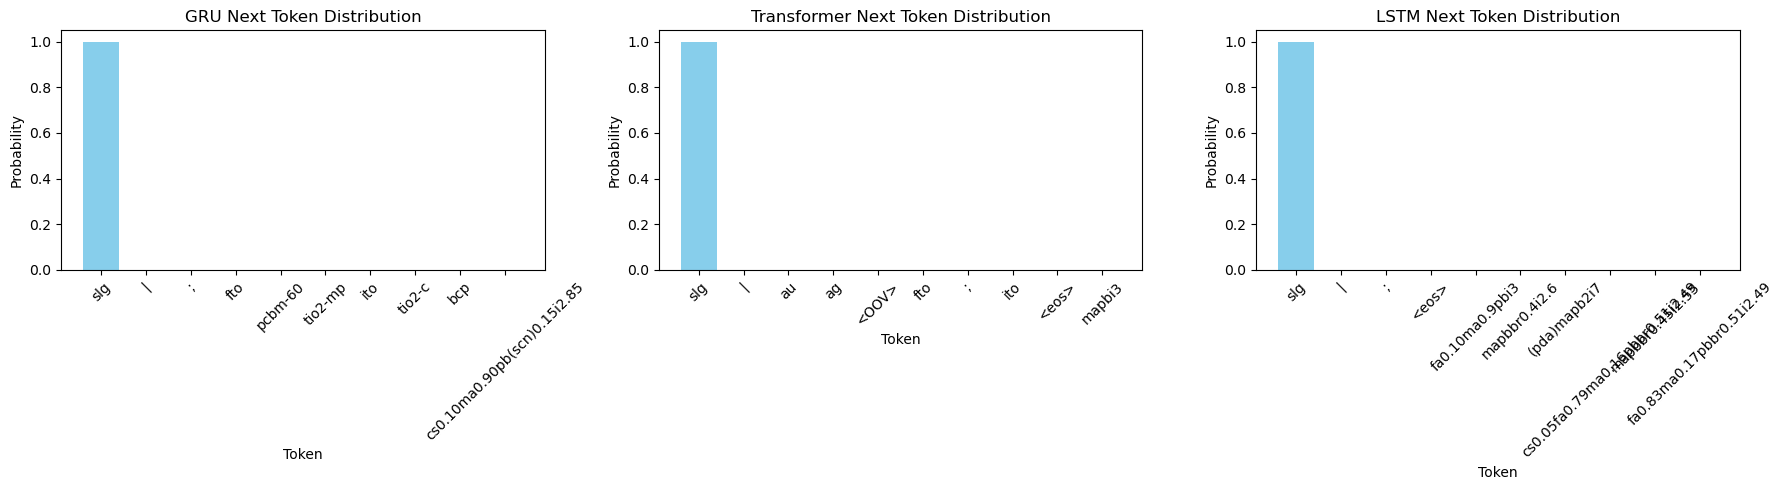

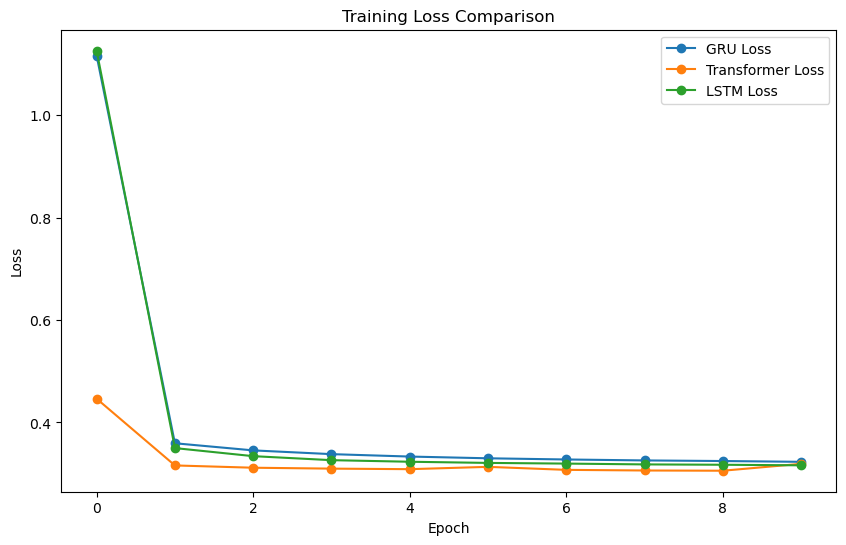

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ===============================
# LOAD TOKENIZER & MAX SEQUENCE LENGTH
# ===============================
with open('tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open('max_sequence_length.pkl', 'rb') as f:
    max_sequence_length = pickle.load(f)

# ===============================
# DEFINE CUSTOM OBJECTS FOR TRANSFORMER
# ===============================
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)
        self.pos_emb = tf.keras.layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim)
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs, use_causal_mask=True)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

custom_objects = {
    "TokenAndPositionEmbedding": TokenAndPositionEmbedding,
    "TransformerBlock": TransformerBlock
}

# ===============================
# LOAD THE THREE MODELS
# ===============================
gru_model = tf.keras.models.load_model('cell_stack_generator_gru_model.h5')
transformer_model = tf.keras.models.load_model('cell_stack_generator_transformer_model.h5', custom_objects=custom_objects)
lstm_model = tf.keras.models.load_model('cell_stack_generator_model.h5')

# ===============================
# DEFINE A UNIFIED GENERATION FUNCTION
# ===============================
def generate_sequence(model, tokenizer, max_sequence_length, seed_text, temperature=1.0):
    """
    Generates a sequence token-by-token using the provided model.
    """
    generated_tokens = seed_text.split()
    # Continue generating until reaching max length or the <EOS> token.
    for _ in range(max_sequence_length - len(generated_tokens)):
        # Convert current generated tokens to sequence of integers.
        seq_int = tokenizer.texts_to_sequences([' '.join(generated_tokens)])[0]
        # Pad to the expected input length (max_sequence_length - 1)
        seq_int = np.pad(seq_int, (0, max_sequence_length - 1 - len(seq_int)), 'constant')
        seq_int = np.expand_dims(seq_int, axis=0)
        
        # Get predictions: shape (1, time_steps, vocab_size)
        preds = model.predict(seq_int, verbose=0)
        # Use the prediction corresponding to the last token position.
        token_index = len(generated_tokens) - 1  
        pred = preds[0, token_index, :]
        
        # Apply temperature scaling.
        pred = np.log(pred + 1e-8) / temperature
        exp_pred = np.exp(pred)
        pred = exp_pred / np.sum(exp_pred)
        
        # Sample the next token.
        next_token = np.random.choice(len(pred), p=pred)
        next_word = tokenizer.index_word.get(next_token, '<OOV>')
        generated_tokens.append(next_word)
        
        # Stop if the end-of-sequence token is generated.
        if next_word == '<EOS>':
            break
            
    return ' '.join(generated_tokens)

# ===============================
# COMPARE GENERATED SEQUENCES
# ===============================
seed_text = '<SOS>'
gru_generated = generate_sequence(gru_model, tokenizer, max_sequence_length, seed_text, temperature=1.0)
transformer_generated = generate_sequence(transformer_model, tokenizer, max_sequence_length, seed_text, temperature=1.0)
lstm_generated = generate_sequence(lstm_model, tokenizer, max_sequence_length, seed_text, temperature=1.0)

print("Generated Sequence Comparison:")
print("GRU:         ", gru_generated)
print("Transformer: ", transformer_generated)
print("LSTM:        ", lstm_generated)

# ===============================
# FUNCTION TO PLOT NEXT-TOKEN PROBABILITY DISTRIBUTION
# ===============================
def plot_next_token_distribution(model, tokenizer, max_sequence_length, seed_text, ax, title):
    """
    For a given seed_text, predicts the next token and plots the top 10 token probabilities.
    """
    # Convert seed text to token indices.
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    # Pad to the expected length.
    seq_int = np.pad(np.array(token_list), (0, max_sequence_length - 1 - len(token_list)), 'constant')
    seq_int = np.expand_dims(seq_int, axis=0)
    
    preds = model.predict(seq_int, verbose=0)
    token_index = len(token_list) - 1
    pred = preds[0, token_index, :]
    
    # Get the top 10 tokens.
    top_indices = np.argsort(pred)[::-1][:10]
    top_probs = pred[top_indices]
    
    # Reverse mapping from index to token.
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}
    top_tokens = [reverse_word_index.get(idx, '<OOV>') for idx in top_indices]
    
    ax.bar(top_tokens, top_probs, color='skyblue')
    ax.set_title(title)
    ax.set_xlabel("Token")
    ax.set_ylabel("Probability")
    ax.tick_params(axis='x', rotation=45)

# ===============================
# PLOT NEXT-TOKEN DISTRIBUTIONS FOR ALL MODELS
# ===============================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
plot_next_token_distribution(gru_model, tokenizer, max_sequence_length, seed_text, axs[0], "GRU Next Token Distribution")
plot_next_token_distribution(transformer_model, tokenizer, max_sequence_length, seed_text, axs[1], "Transformer Next Token Distribution")
plot_next_token_distribution(lstm_model, tokenizer, max_sequence_length, seed_text, axs[2], "LSTM Next Token Distribution")
plt.tight_layout()
plt.show()

# ===============================
# (OPTIONAL) TRAINING DYNAMICS VISUALIZATION
# ===============================
# If you saved training histories (e.g., as pickle files), you could load and compare them:
with open('gru_history.pkl', 'rb') as f:
    gru_history = pickle.load(f)
with open('transformer_history.pkl', 'rb') as f:
    transformer_history = pickle.load(f)
with open('lstm_history.pkl', 'rb') as f:
    lstm_history = pickle.load(f)

# Plot training loss curves:
plt.figure(figsize=(10,6))
plt.plot(gru_history['loss'], label='GRU Loss', marker='o')
plt.plot(transformer_history['loss'], label='Transformer Loss', marker='o')
plt.plot(lstm_history['loss'], label='LSTM Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()

plt.show()


2025-02-26 15:21:13.215213: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Generated Sequence Comparison:
GRU:          <SOS> slg | fto ; tio2-c | tio2-mp ; mapbi3 ; spiro-meotad ; au <eos>
Transformer:  <SOS> slg | fto ; tio2-c ; mapbi3 ; spiro-meotad ; au <eos> <OOV> <eos>
LSTM:         <SOS> slg | fto ; tio2-c ; cs0.15fa0.85pbi3 ; spiro-meotad ; ag <eos> <OOV> ;


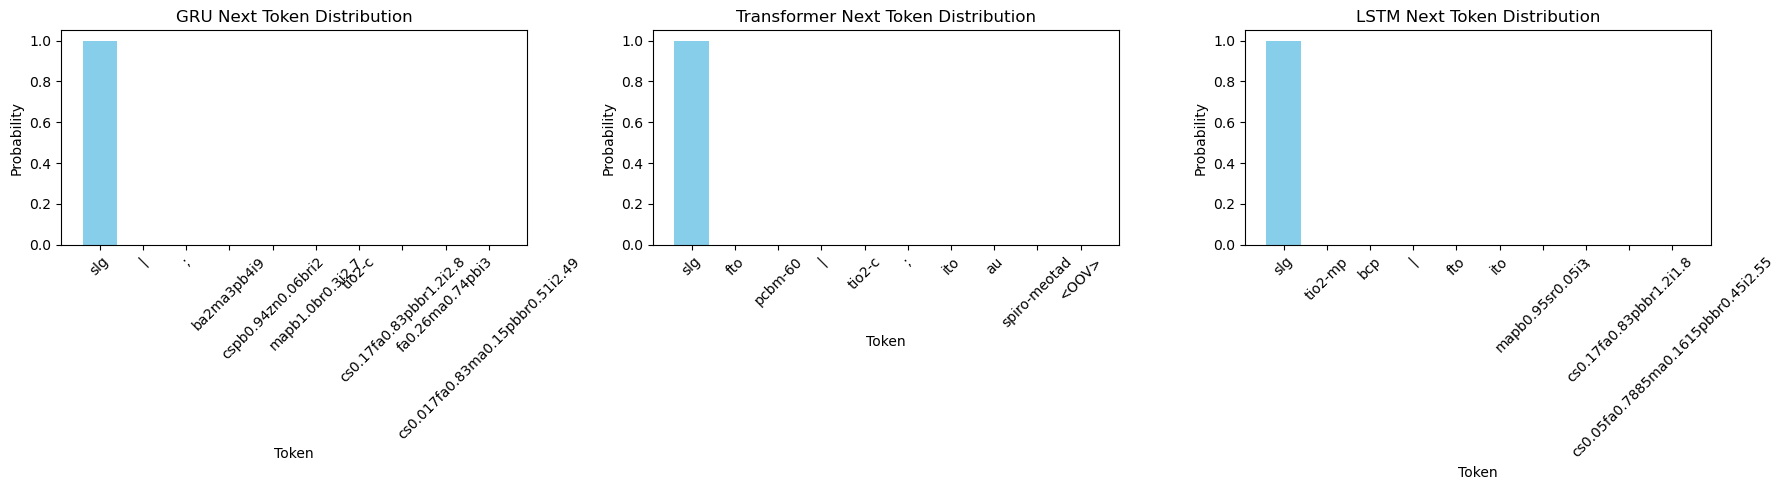

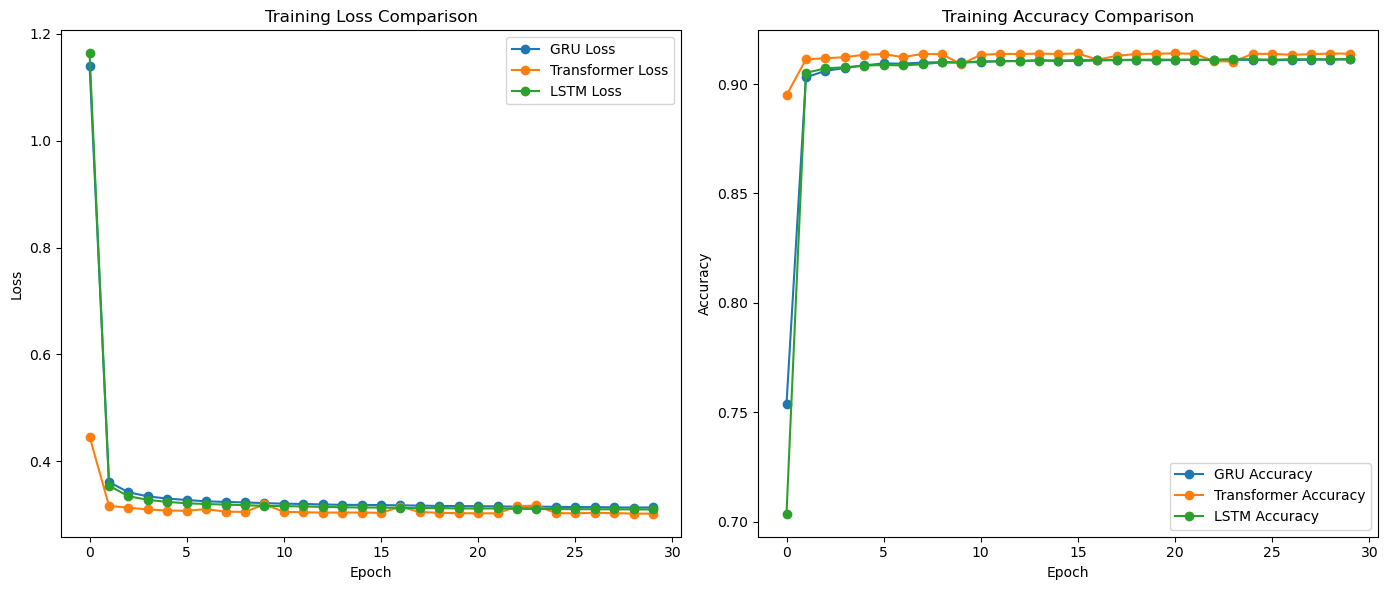

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ===============================
# LOAD TOKENIZER & MAX SEQUENCE LENGTH
# ===============================
with open('tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open('max_sequence_length.pkl', 'rb') as f:
    max_sequence_length = pickle.load(f)

# ===============================
# DEFINE CUSTOM OBJECTS FOR TRANSFORMER
# ===============================
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)
        self.pos_emb = tf.keras.layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim)
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs, use_causal_mask=True)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

custom_objects = {
    "TokenAndPositionEmbedding": TokenAndPositionEmbedding,
    "TransformerBlock": TransformerBlock
}

# ===============================
# LOAD THE THREE MODELS
# ===============================
gru_model = tf.keras.models.load_model('cell_stack_generator_gru_model.h5')
transformer_model = tf.keras.models.load_model('cell_stack_generator_transformer_model.h5', custom_objects=custom_objects)
lstm_model = tf.keras.models.load_model('cell_stack_generator_model.h5')

# ===============================
# DEFINE A UNIFIED GENERATION FUNCTION
# ===============================
def generate_sequence(model, tokenizer, max_sequence_length, seed_text, temperature=1.0):
    """
    Generates a sequence token-by-token using the provided model.
    """
    generated_tokens = seed_text.split()
    # Continue generating until reaching max length or the <EOS> token.
    for _ in range(max_sequence_length - len(generated_tokens)):
        # Convert current generated tokens to sequence of integers.
        seq_int = tokenizer.texts_to_sequences([' '.join(generated_tokens)])[0]
        # Pad to the expected input length (max_sequence_length - 1)
        seq_int = np.pad(seq_int, (0, max_sequence_length - 1 - len(seq_int)), 'constant')
        seq_int = np.expand_dims(seq_int, axis=0)
        
        # Get predictions: shape (1, time_steps, vocab_size)
        preds = model.predict(seq_int, verbose=0)
        # Use the prediction corresponding to the last token position.
        token_index = len(generated_tokens) - 1  
        pred = preds[0, token_index, :]
        
        # Apply temperature scaling.
        pred = np.log(pred + 1e-8) / temperature
        exp_pred = np.exp(pred)
        pred = exp_pred / np.sum(exp_pred)
        
        # Sample the next token.
        next_token = np.random.choice(len(pred), p=pred)
        next_word = tokenizer.index_word.get(next_token, '<OOV>')
        generated_tokens.append(next_word)
        
        # Stop if the end-of-sequence token is generated.
        if next_word == '<EOS>':
            break
            
    return ' '.join(generated_tokens)

# ===============================
# COMPARE GENERATED SEQUENCES
# ===============================
seed_text = '<SOS>'
gru_generated = generate_sequence(gru_model, tokenizer, max_sequence_length, seed_text, temperature=1.0)
transformer_generated = generate_sequence(transformer_model, tokenizer, max_sequence_length, seed_text, temperature=1.0)
lstm_generated = generate_sequence(lstm_model, tokenizer, max_sequence_length, seed_text, temperature=1.0)

print("Generated Sequence Comparison:")
print("GRU:         ", gru_generated)
print("Transformer: ", transformer_generated)
print("LSTM:        ", lstm_generated)

# ===============================
# FUNCTION TO PLOT NEXT-TOKEN PROBABILITY DISTRIBUTION
# ===============================
def plot_next_token_distribution(model, tokenizer, max_sequence_length, seed_text, ax, title):
    """
    For a given seed_text, predicts the next token and plots the top 10 token probabilities.
    """
    # Convert seed text to token indices.
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    # Pad to the expected length.
    seq_int = np.pad(np.array(token_list), (0, max_sequence_length - 1 - len(token_list)), 'constant')
    seq_int = np.expand_dims(seq_int, axis=0)
    
    preds = model.predict(seq_int, verbose=0)
    token_index = len(token_list) - 1
    pred = preds[0, token_index, :]
    
    # Get the top 10 tokens.
    top_indices = np.argsort(pred)[::-1][:10]
    top_probs = pred[top_indices]
    
    # Reverse mapping from index to token.
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}
    top_tokens = [reverse_word_index.get(idx, '<OOV>') for idx in top_indices]
    
    ax.bar(top_tokens, top_probs, color='skyblue')
    ax.set_title(title)
    ax.set_xlabel("Token")
    ax.set_ylabel("Probability")
    ax.tick_params(axis='x', rotation=45)

# ===============================
# PLOT NEXT-TOKEN DISTRIBUTIONS FOR ALL MODELS
# ===============================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
plot_next_token_distribution(gru_model, tokenizer, max_sequence_length, seed_text, axs[0], "GRU Next Token Distribution")
plot_next_token_distribution(transformer_model, tokenizer, max_sequence_length, seed_text, axs[1], "Transformer Next Token Distribution")
plot_next_token_distribution(lstm_model, tokenizer, max_sequence_length, seed_text, axs[2], "LSTM Next Token Distribution")
plt.tight_layout()
plt.show()

# ===============================
# (OPTIONAL) TRAINING DYNAMICS VISUALIZATION
# ===============================
# Load training histories saved as pickle files
with open('gru_history.pkl', 'rb') as f:
    gru_history = pickle.load(f)
with open('transformer_history.pkl', 'rb') as f:
    transformer_history = pickle.load(f)
with open('lstm_history.pkl', 'rb') as f:
    lstm_history = pickle.load(f)

# Create subplots to compare both loss and accuracy.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot training loss curves.
ax1.plot(gru_history['loss'], label='GRU Loss', marker='o')
ax1.plot(transformer_history['loss'], label='Transformer Loss', marker='o')
ax1.plot(lstm_history['loss'], label='LSTM Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()

# Plot training accuracy curves.
ax2.plot(gru_history['accuracy'], label='GRU Accuracy', marker='o')
ax2.plot(transformer_history['accuracy'], label='Transformer Accuracy', marker='o')
ax2.plot(lstm_history['accuracy'], label='LSTM Accuracy', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy Comparison')
ax2.legend()

plt.tight_layout()
plt.show()


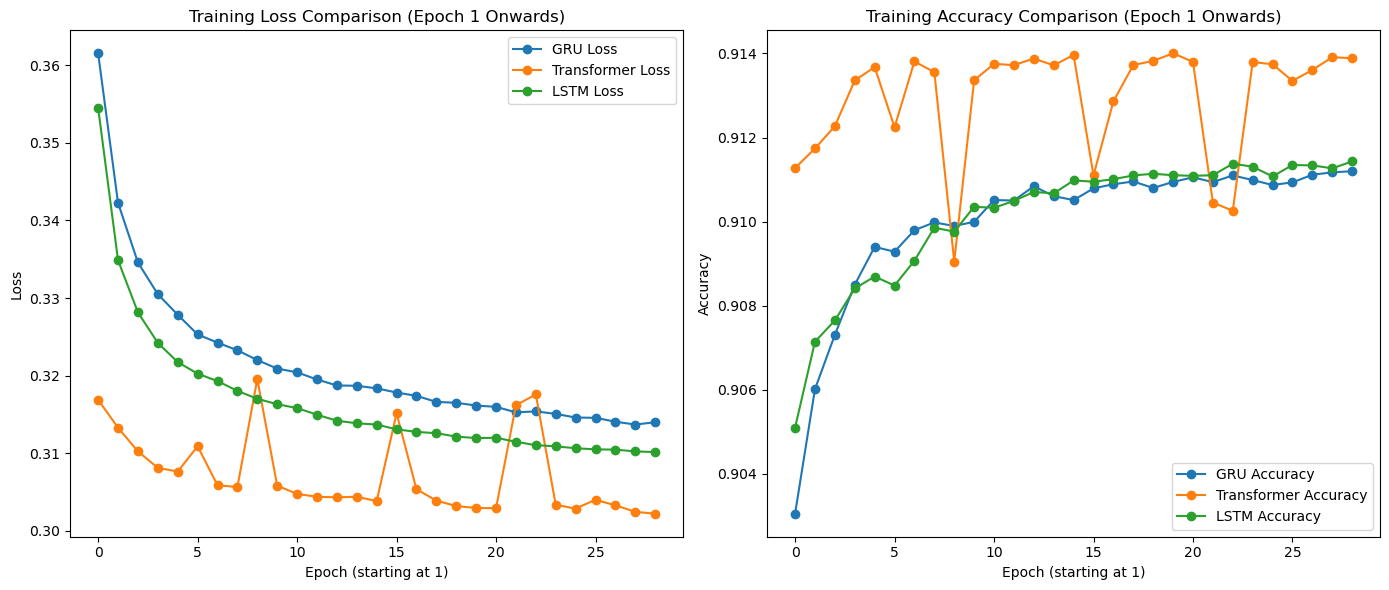

In [3]:
# ===============================
# PLOT TRAINING DYNAMICS IGNORING EPOCH 0
# ===============================
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6))

# Plot training loss curves ignoring epoch 0.
ax3.plot(gru_history['loss'][1:], label='GRU Loss', marker='o')
ax3.plot(transformer_history['loss'][1:], label='Transformer Loss', marker='o')
ax3.plot(lstm_history['loss'][1:], label='LSTM Loss', marker='o')
ax3.set_xlabel('Epoch (starting at 1)')
ax3.set_ylabel('Loss')
ax3.set_title('Training Loss Comparison (Epoch 1 Onwards)')
ax3.legend()

# Plot training accuracy curves ignoring epoch 0.
ax4.plot(gru_history['accuracy'][1:], label='GRU Accuracy', marker='o')
ax4.plot(transformer_history['accuracy'][1:], label='Transformer Accuracy', marker='o')
ax4.plot(lstm_history['accuracy'][1:], label='LSTM Accuracy', marker='o')
ax4.set_xlabel('Epoch (starting at 1)')
ax4.set_ylabel('Accuracy')
ax4.set_title('Training Accuracy Comparison (Epoch 1 Onwards)')
ax4.legend()

plt.tight_layout()
plt.show()


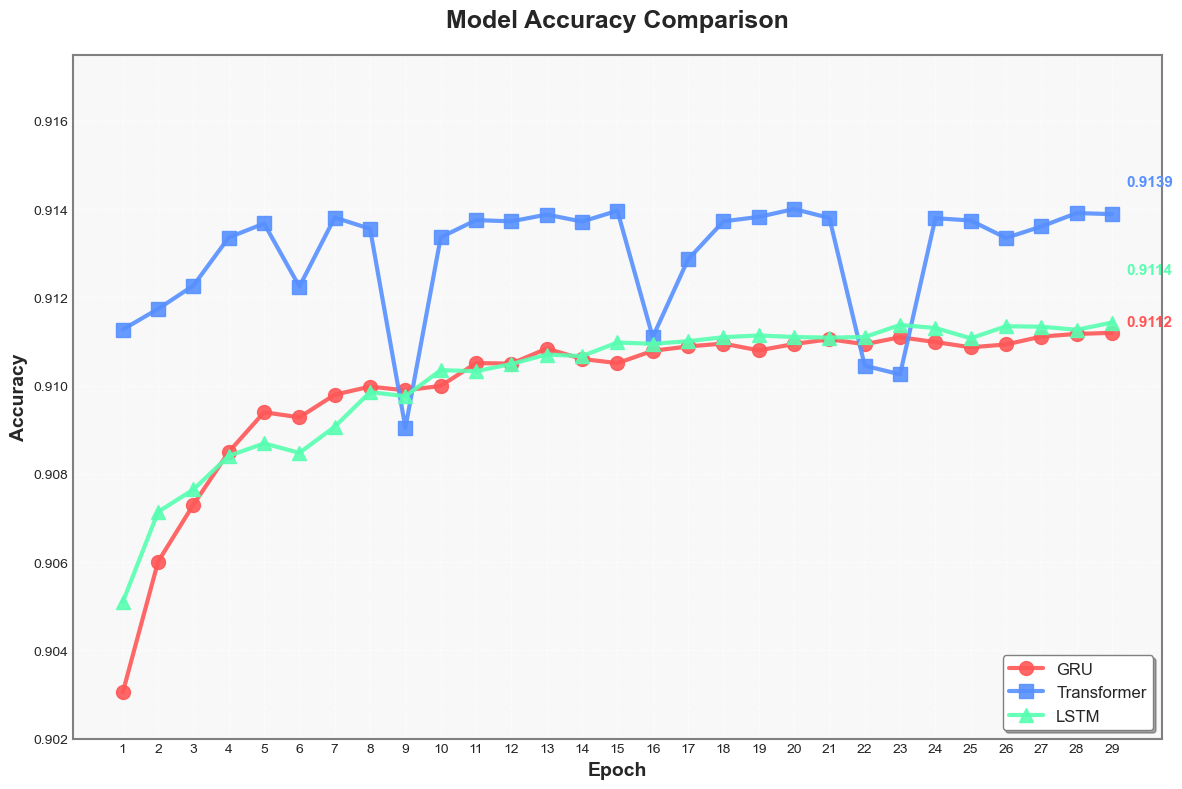

In [6]:
# ===============================
# PLOT ACCURACY GRAPH WITH ENHANCED STYLING
# ===============================
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Set a modern style
plt.style.use('seaborn-v0_8-darkgrid')

# Create a single figure with more appealing size ratio
fig, ax = plt.subplots(figsize=(12, 8))

# Define a vibrant color palette
colors = ['#FF5757', '#5790FF', '#57FFB1']  # Red, Blue, Green
line_width = 3
marker_size = 10

# Create x-axis data (for better epoch labeling)
epochs = np.arange(1, len(gru_history['accuracy'][1:]) + 1)

# Plot with enhanced styling
ax.plot(epochs, gru_history['accuracy'][1:], label='GRU', 
        color=colors[0], linewidth=line_width, marker='o', 
        markersize=marker_size, alpha=0.9)
ax.plot(epochs, transformer_history['accuracy'][1:], label='Transformer', 
        color=colors[1], linewidth=line_width, marker='s', 
        markersize=marker_size, alpha=0.9)
ax.plot(epochs, lstm_history['accuracy'][1:], label='LSTM', 
        color=colors[2], linewidth=line_width, marker='^', 
        markersize=marker_size, alpha=0.9)

# Enhance grid and background
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_facecolor('#f8f8f8')

# Add better labels
ax.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Model Accuracy Comparison', fontsize=18, fontweight='bold', pad=20)

# Improve legend
ax.legend(fontsize=12, frameon=True, facecolor='white', edgecolor='gray', 
          shadow=True, loc='lower right')

# Set x-axis ticks to show every epoch
ax.set_xticks(epochs)

# Set y-axis to start at 0.902 and end at 0.9175
ax.set_ylim([0.902, 0.9175])

# Add annotations for final accuracy values
final_epoch = len(epochs)
for i, history in enumerate([gru_history, transformer_history, lstm_history]):
    final_acc = history['accuracy'][final_epoch]
    ax.annotate(f'{final_acc:.4f}', 
                xy=(final_epoch, final_acc),
                xytext=(10, 5 + i*15),  # Offset text position
                textcoords='offset points',
                fontsize=11,
                fontweight='bold',
                color=colors[i])

# Make spines (borders) more visible
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('gray')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()